In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Generate sample 2D data for two classes
np.random.seed(42)
class1 = np.random.multivariate_normal(mean=[2, 2], cov=[[1, 0.5], [0.5, 1]], size=10)
class2 = np.random.multivariate_normal(mean=[5, 5], cov=[[1, -0.5], [-0.5, 1]], size=10)

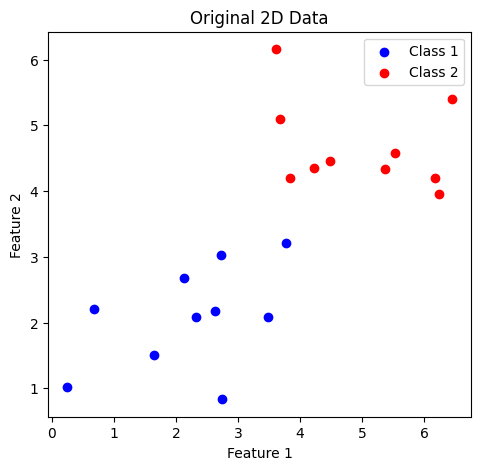

In [3]:
# Plot original 2D data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(class1[:, 0], class1[:, 1], color='blue', label='Class 1')
plt.scatter(class2[:, 0], class2[:, 1], color='red', label='Class 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original 2D Data')
plt.legend()

In [10]:
# Compute mean vectors for each class
mean1 = np.mean(class1, axis=0)
mean2 = np.mean(class2, axis=0)


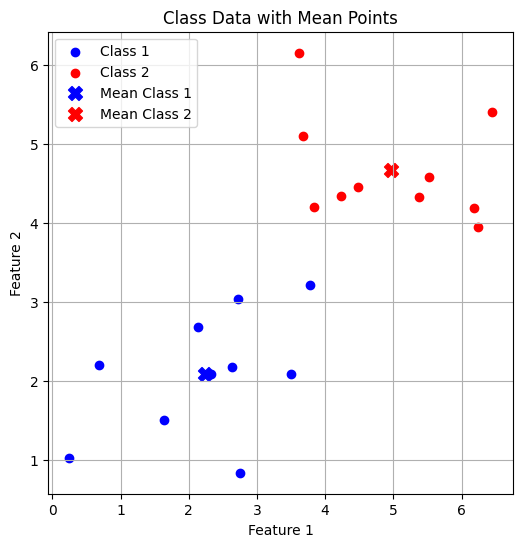

In [9]:
# Plot original 2D data
plt.figure(figsize=(6, 6))
plt.scatter(class1[:, 0], class1[:, 1], color='blue', label='Class 1')
plt.scatter(class2[:, 0], class2[:, 1], color='red', label='Class 2')

# Plot mean points
plt.scatter(mean1[0], mean1[1], color='blue', marker='X', s=100, label='Mean Class 1')
plt.scatter(mean2[0], mean2[1], color='red', marker='X', s=100, label='Mean Class 2')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Class Data with Mean Points')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Compute within-class scatter matrix Sw
Sw = np.zeros((2, 2))
for sample in class1:
    diff = (sample - mean1).reshape(2, 1)
    Sw += diff @ diff.T
for sample in class2:
    diff = (sample - mean2).reshape(2, 1)
    Sw += diff @ diff.T
Sw

array([[22.68316332,  1.51827267],
       [ 1.51827267,  9.76990938]])

In [12]:
# Compute between-class scatter matrix Sb
mean_diff = (mean1 - mean2).reshape(2, 1)
Sb = mean_diff @ mean_diff.T
Sb

array([[7.41961598, 7.05947816],
       [7.05947816, 6.71682092]])

In [14]:
# Solve for the eigenvalues and eigenvectors of Sw^(-1) Sb
eigvals, eigvecs = np.linalg.eig(np.linalg.inv(Sw) @ Sb)

# Choose the eigenvector with the largest eigenvalue
w = eigvecs[:, np.argmax(eigvals)]


In [17]:
eigvals, eigvecs, w

(array([1.11022302e-16, 9.27517223e-01]),
 array([[-0.68930576, -0.38325703],
        [ 0.72447055, -0.92364173]]),
 array([-0.38325703, -0.92364173]))

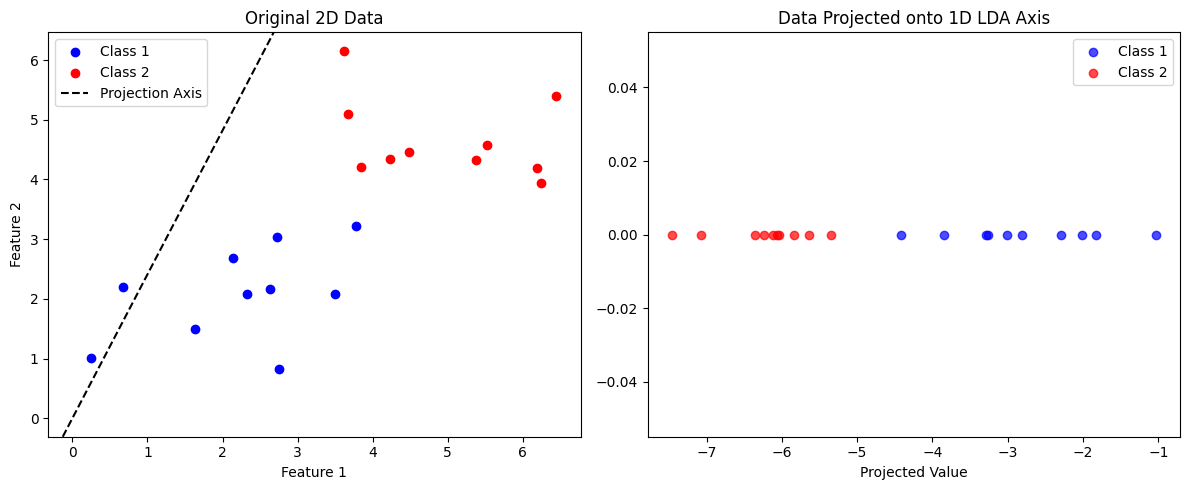

In [5]:
# Project data onto the chosen eigenvector
proj1 = class1 @ w
proj2 = class2 @ w

# Plot original 2D data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(class1[:, 0], class1[:, 1], color='blue', label='Class 1')
plt.scatter(class2[:, 0], class2[:, 1], color='red', label='Class 2')
plt.axline((0, 0), slope=w[1]/w[0], color='black', linestyle='--', label='Projection Axis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original 2D Data')
plt.legend()

# Plot projected 1D data
plt.subplot(1, 2, 2)
plt.scatter(proj1, np.zeros_like(proj1), color='blue', label='Class 1', alpha=0.7)
plt.scatter(proj2, np.zeros_like(proj2), color='red', label='Class 2', alpha=0.7)
plt.xlabel('Projected Value')
plt.title('Data Projected onto 1D LDA Axis')
plt.legend()

plt.tight_layout()
plt.show()
